In [5]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [6]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [7]:
# There is empty space in age columns
df['Age'].fillna(df['Age'].mean(),inplace=True)

C:\Users\Isha\AppData\Local\Temp\ipykernel_3824\2897423414.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [8]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [9]:
x=df.iloc[:,1:3]
y=df.iloc[:,0]

In [10]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

C:\Users\Isha\AppData\Local\Temp\ipykernel_3824\543285974.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


Text(0.5, 1.0, 'Age QQ Plot')

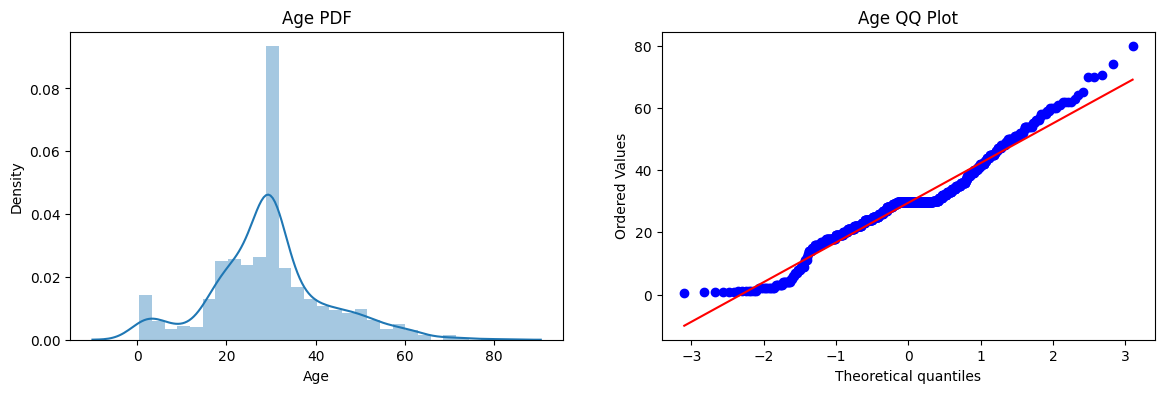

In [11]:
plt.figure(figsize=(14,4))     #Size of figure
plt.subplot(121)                #left side plot
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)              #Right side plot
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Age QQ Plot')

C:\Users\Isha\AppData\Local\Temp\ipykernel_3824\2790818795.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


Text(0.5, 1.0, 'Fare QQ plot')

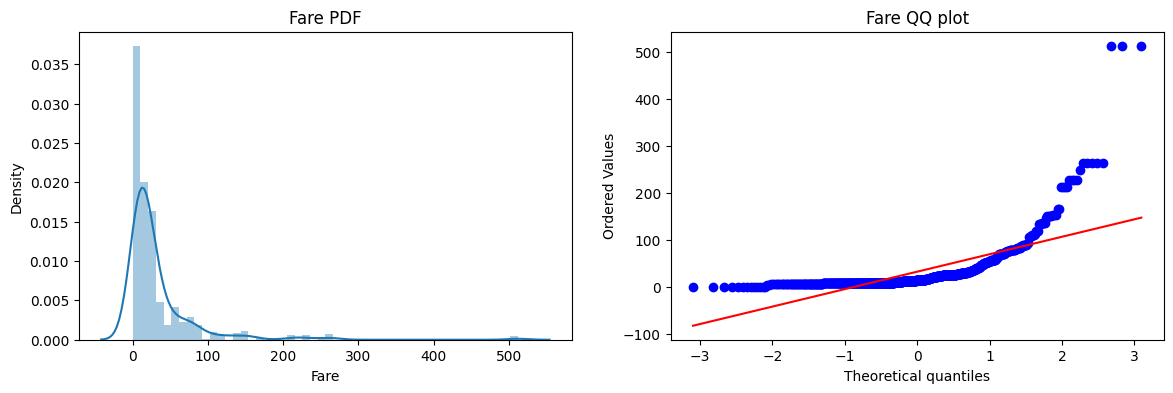

In [12]:
plt.figure(figsize=(14,4))      #Size of figure
plt.subplot(121)                #Left side plot
sns.distplot(X_train['Fare'])
plt.title('Fare PDF')

plt.subplot(122)                  #Right side plot
stats.probplot(X_train['Fare'],dist="norm",plot=plt)
plt.title('Fare QQ plot')

In [13]:
clf1=LogisticRegression()
clf2=DecisionTreeClassifier()

In [14]:
clf1.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred1=clf1.predict(X_test)
y_pred2=clf2.predict(X_test)

print('Accuracy LR:',accuracy_score(y_test,y_pred1))
print('Accuracy DT:',accuracy_score(y_test,y_pred2))

Accuracy LR: 0.6480446927374302
Accuracy DT: 0.6927374301675978


# Use of function transformer

In [16]:
trf=FunctionTransformer(func=np.log1p)

In [17]:
# Fitting on X_train and X_test
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.transform(X_test)

In [18]:
# Predict accuracy after functiontransformer()

clf1.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred1=clf1.predict(X_test)
y_pred2=clf2.predict(X_test)

print('Accuracy LR:',accuracy_score(y_test,y_pred1))
print('Accuracy DT:',accuracy_score(y_test,y_pred2))


Accuracy LR: 0.7374301675977654
Accuracy DT: 0.5865921787709497


In [19]:
from sklearn.pipeline import Pipeline,make_pipeline
# Appling cross_val_score for more reliable accuracy

#Pipeline for logictic regression
pipe1=Pipeline([
    ('transform',trf),
    ('model',clf1)
])

#Pipeline for Decision Tree
pipe2=Pipeline([
    ('transform',trf),
    ('model',clf2)
])

print('LR',np.mean(cross_val_score(pipe1,x,y,scoring='accuracy',cv=10)))
print('DT',np.mean(cross_val_score(pipe2,x,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6566042446941324


Text(0.5, 1.0, 'Age after log')

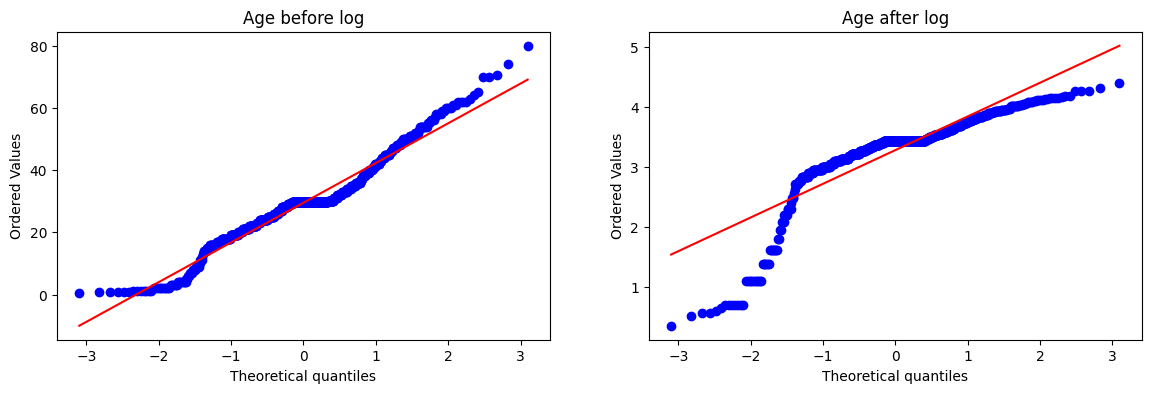

In [20]:
# QQ plot for age    -->Forcefully applied log on age due to which it is not showing correctly
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Age before log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'],dist="norm",plot=plt)
plt.title('Age after log')

Text(0.5, 1.0, 'Fare after log')

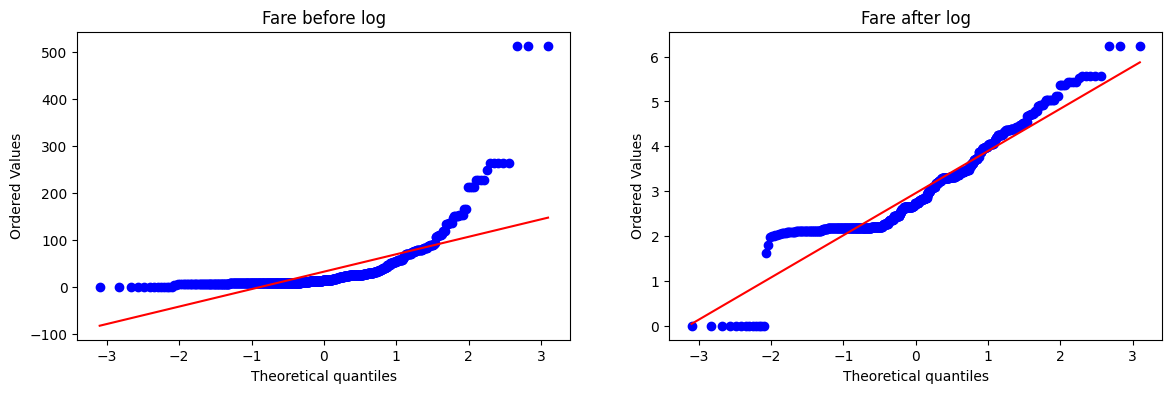

In [21]:
# QQ plot for fare
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('Fare before log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'],dist="norm",plot=plt)
plt.title('Fare after log')

In [22]:
# Now perform Function transformer (log) only and passthrough others by using ColumnTransformer
trf2=ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

# Transforming train and test data
X_train_transformed2=trf2.fit_transform(X_train)
X_test_transformed2=trf2.transform(X_test)

# Training the model
clf1.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)

#Prediction
y_pred1=clf1.predict(X_test_transformed2)
y_pred2=clf2.predict(X_test_transformed2)


#Accuracy
print('Accuracy LR:',accuracy_score(y_test,y_pred1))
print('Accuracy DT:',accuracy_score(y_test,y_pred2))

Accuracy LR: 0.6703910614525139
Accuracy DT: 0.6759776536312849


In [23]:
# Appling cross_val_score for more reliable accuracy
X_transformed2=trf2.fit_transform(x)

print('LR',np.mean(cross_val_score(clf1,X_transformed2,y,scoring='accuracy',cv=10)))
print('DT',np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6644818976279651


In [54]:
#Other fuction transformer such as reciprocal , sq,sqrt
def apply_transform(transform):
    X=df.iloc[:,1:3]
    y=df.iloc[:,0]

    trf3=ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans=trf3.fit_transform(X)
    
    print("Accuracy",np.mean(cross_val_score(clf1,X_trans,y,scoring='accuracy',cv=10)))
    
    # QQ plot for fare
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    stats.probplot(X_train_transformed['Fare'],dist='norm',plot=plt)
    plt.title('Fare before transform')
    
    plt.subplot(122)
    stats.probplot(X_train_transformed['Fare'],dist="norm",plot=plt)
    plt.title('Fare after transform')

    plt.show()

Accuracy 0.6589013732833957


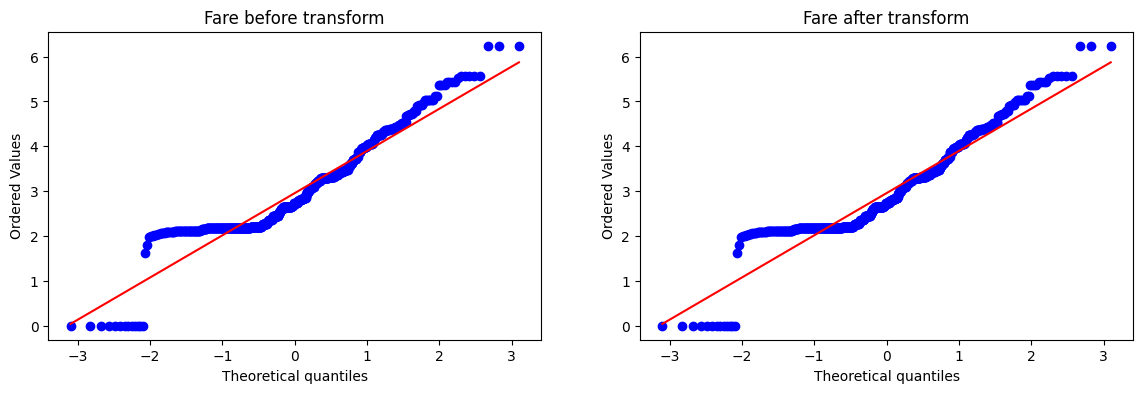

In [46]:
apply_transform(lambda x:x)

Accuracy 0.6431335830212235


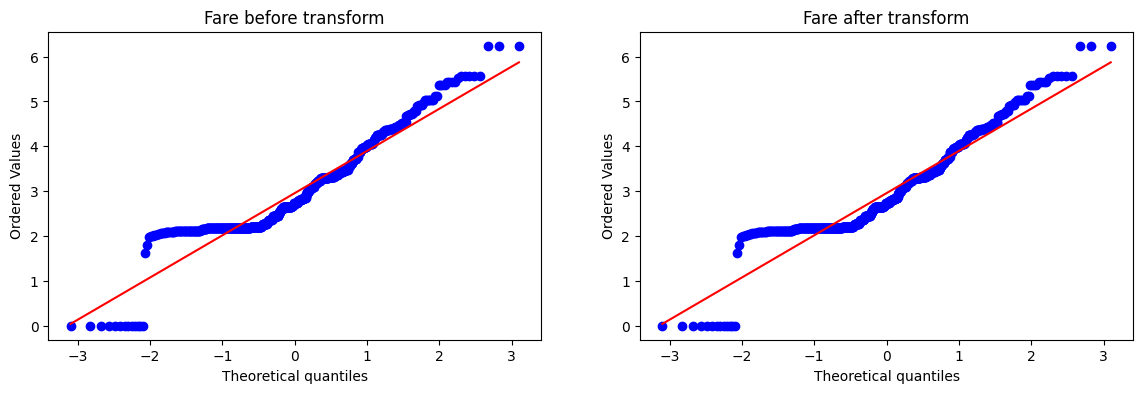

In [48]:
apply_transform(lambda x:x**2)

Accuracy 0.6589013732833957


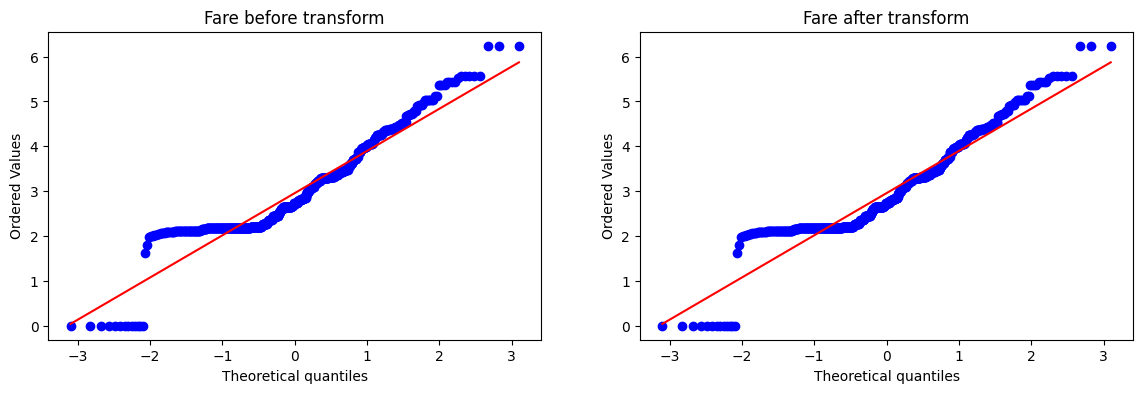

In [50]:
apply_transform(lambda x:x**1/2)

Accuracy 0.61729088639201


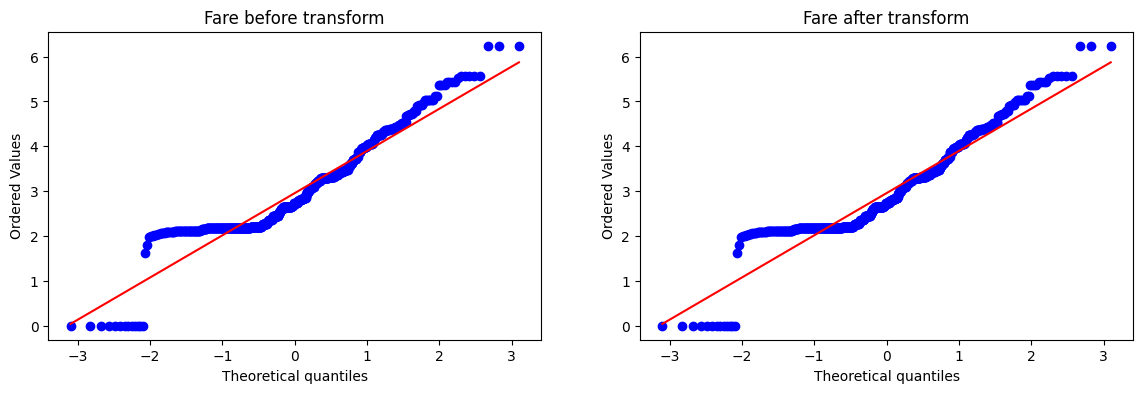

In [52]:
apply_transform(lambda x:1/(x+0.1))